# Model Training — Job Scam Analyzer

This notebook trains and evaluates two models:
1. **Random Forest** — interpretable baseline
2. **XGBoost** — best performance model



In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (roc_auc_score, roc_curve,
                                      precision_recall_curve,
                                      classification_report,
                                      confusion_matrix)
from xgboost import XGBClassifier

os.makedirs('./outputs', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d2e',
    'axes.edgecolor':   '#2d3154',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2d3154',
    'grid.linewidth':   0.5,
})
ACCENT = '#7c6af7'
RED    = '#ef4444'
GREEN  = '#10b981'
YELLOW = '#f59e0b'

print("  Imports done")

  Imports done


In [12]:
data          = np.load('./data/features.npz')
X             = data['X']
y             = data['y']
feature_names = np.load('./data/feature_names.npy',
                        allow_pickle=True).tolist()

print(f"    Loaded feature matrix: {X.shape}")
print(f"    Fraud cases:  {y.sum():,}  ({y.mean()*100:.1f}%)")
print(f"    Legit cases:  {(y==0).sum():,}  ({(y==0).mean()*100:.1f}%)")
print(f"    Total features: {len(feature_names)}")

    Loaded feature matrix: (17880, 317)
    Fraud cases:  866  (4.8%)
    Legit cases:  17,014  (95.2%)
    Total features: 317


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y       
)

print(f"    Split done")
print(f"    Train: {X_train.shape[0]:,} rows  |  fraud: {y_train.sum():,}")
print(f"    Test:  {X_test.shape[0]:,} rows   |  fraud: {y_test.sum():,}")

    Split done
    Train: 14,304 rows  |  fraud: 693
    Test:  3,576 rows   |  fraud: 173


## Class Imbalance Strategy

Only 4.8% of postings are fraudulent. But the model learns to predict "legit" for everything and gets
95% accuracy while catching zero scams.

- Random Forest → `class_weight='balanced'` (auto-adjusts sample weights)
- XGBoost → `scale_pos_weight` = (legit count / fraud count) ≈ 19.8
  (tells XGBoost: each fraud case is worth ~20 legit cases)

In [14]:
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight for XGBoost: {scale_weight:.1f}")

models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale_weight,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
}

results = {}

for name, model in models.items():
    print(f"\n  Training {name}...")
    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)

    # 5-fold cross validation
    cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_aucs = cross_val_score(model, X_train, y_train,
                              cv=cv, scoring='roc_auc', n_jobs=-1)

    results[name] = {
        'model':    model,
        'y_prob':   y_prob,
        'test_auc': auc,
        'cv_mean':  cv_aucs.mean(),
        'cv_std':   cv_aucs.std(),
    }

    print(f"     {name}")
    print(f"      Test AUC : {auc:.4f}")
    print(f"      CV AUC   : {cv_aucs.mean():.4f} ± {cv_aucs.std():.4f}")


scale_pos_weight for XGBoost: 19.6

  Training Random Forest...
     Random Forest
      Test AUC : 0.9680
      CV AUC   : 0.9618 ± 0.0098

  Training XGBoost...
     XGBoost
      Test AUC : 0.9807
      CV AUC   : 0.9778 ± 0.0076


## ROC Curve Comparison

ROC curve shows the tradeoff between catching real scams
(true positive rate) vs falsely flagging legit jobs
(false positive rate) at every possible threshold.

AUC = area under this curve. Higher = better.
Random classifier = 0.50. Perfect classifier = 1.00.

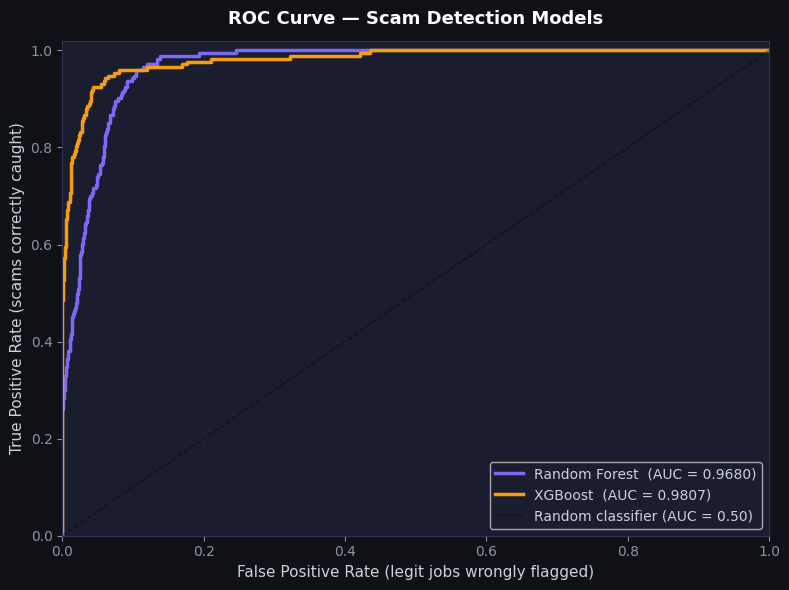

  Saved: ./outputs/roc_curves.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

colors = [ACCENT, YELLOW]

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, linewidth=2.5, color=color,
            label=f"{name}  (AUC = {res['test_auc']:.4f})")

ax.plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1,
        label='Random classifier (AUC = 0.50)')

ax.set_xlabel('False Positive Rate (legit jobs wrongly flagged)', fontsize=11)
ax.set_ylabel('True Positive Rate (scams correctly caught)',      fontsize=11)
ax.set_title('ROC Curve — Scam Detection Models', fontsize=13,
             fontweight='bold', color='white', pad=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('./outputs/roc_curves.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/roc_curves.png")

## Threshold Tuning

Default threshold = 0.50 (anything above 50% → predicted scam).

This is wrong for fraud detection because:
- Missing a real scam = job seeker loses money / data
- False alarm on a legit job = minor inconvenience

So we tune the threshold to **maximise F2 score**,
which weights recall twice as heavily as precision.
Our aim is to catch as many real scams as possible.

In [16]:
# Use best model by AUC
best_name  = max(results, key=lambda k: results[k]['test_auc'])
best_res   = results[best_name]
y_prob     = best_res['y_prob']

print(f"Best model: {best_name}  (AUC: {best_res['test_auc']:.4f})\n")

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# F2 score — recall weighted 2x more than precision
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-9)
best_idx   = np.argmax(f2_scores)
opt_thresh = thresholds[best_idx]

print(f"Default threshold (0.50):")
y_pred_default = (y_prob >= 0.50).astype(int)
print(classification_report(y_test, y_pred_default,
                             target_names=['Legit','Scam']))

print(f"\nOptimal threshold ({opt_thresh:.3f}) — F2 maximised:")
y_pred_optimal = (y_prob >= opt_thresh).astype(int)
print(classification_report(y_test, y_pred_optimal,
                             target_names=['Legit','Scam']))


Best model: XGBoost  (AUC: 0.9807)

Default threshold (0.50):
              precision    recall  f1-score   support

       Legit       0.99      0.98      0.98      3403
        Scam       0.66      0.81      0.73       173

    accuracy                           0.97      3576
   macro avg       0.82      0.89      0.85      3576
weighted avg       0.97      0.97      0.97      3576


Optimal threshold (0.273) — F2 maximised:
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98      3403
        Scam       0.53      0.92      0.67       173

    accuracy                           0.96      3576
   macro avg       0.76      0.94      0.82      3576
weighted avg       0.97      0.96      0.96      3576



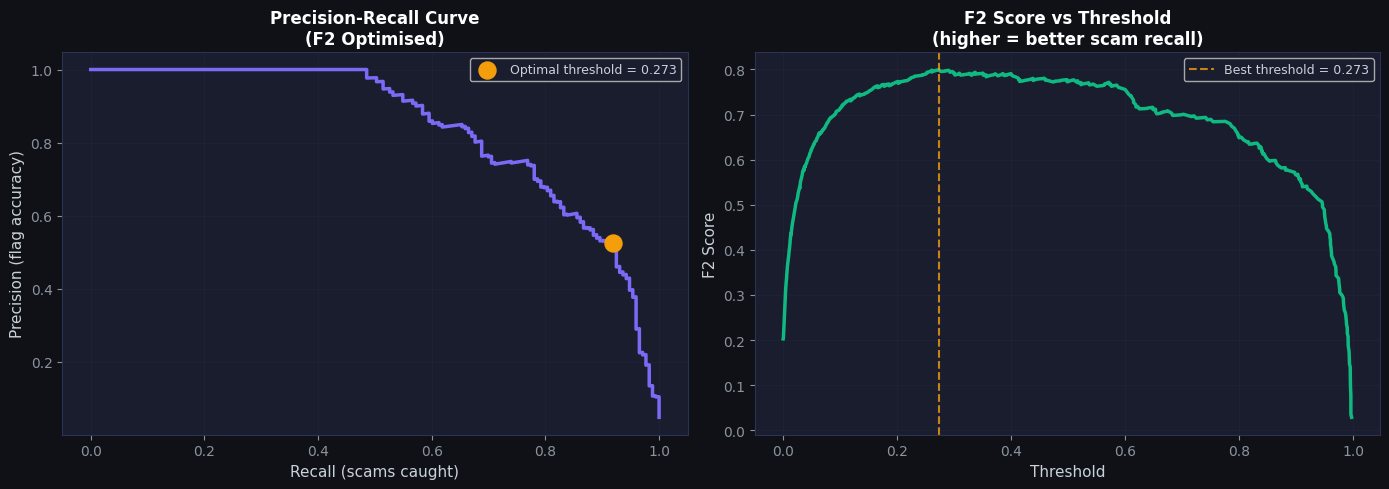

  Saved: ./outputs/precision_recall.png


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')

for ax in [ax1, ax2]:
    ax.set_facecolor('#1a1d2e')
    ax.grid(alpha=0.3)

# Left — Precision-Recall curve
ax1.plot(recall, precision, color=ACCENT, linewidth=2.5)
ax1.scatter(recall[best_idx], precision[best_idx],
            color=YELLOW, s=150, zorder=5,
            label=f'Optimal threshold = {opt_thresh:.3f}')
ax1.set_xlabel('Recall (scams caught)',    fontsize=11)
ax1.set_ylabel('Precision (flag accuracy)', fontsize=11)
ax1.set_title('Precision-Recall Curve\n(F2 Optimised)',
              fontsize=12, fontweight='bold', color='white')
ax1.legend(fontsize=9)

# Right — F2 score across thresholds
ax2.plot(thresholds, f2_scores[:-1], color=GREEN, linewidth=2.5)
ax2.axvline(x=opt_thresh, color=YELLOW, linestyle='--',
            alpha=0.8, label=f'Best threshold = {opt_thresh:.3f}')
ax2.set_xlabel('Threshold',   fontsize=11)
ax2.set_ylabel('F2 Score',    fontsize=11)
ax2.set_title('F2 Score vs Threshold\n(higher = better scam recall)',
              fontsize=12, fontweight='bold', color='white')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('./outputs/precision_recall.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/precision_recall.png")

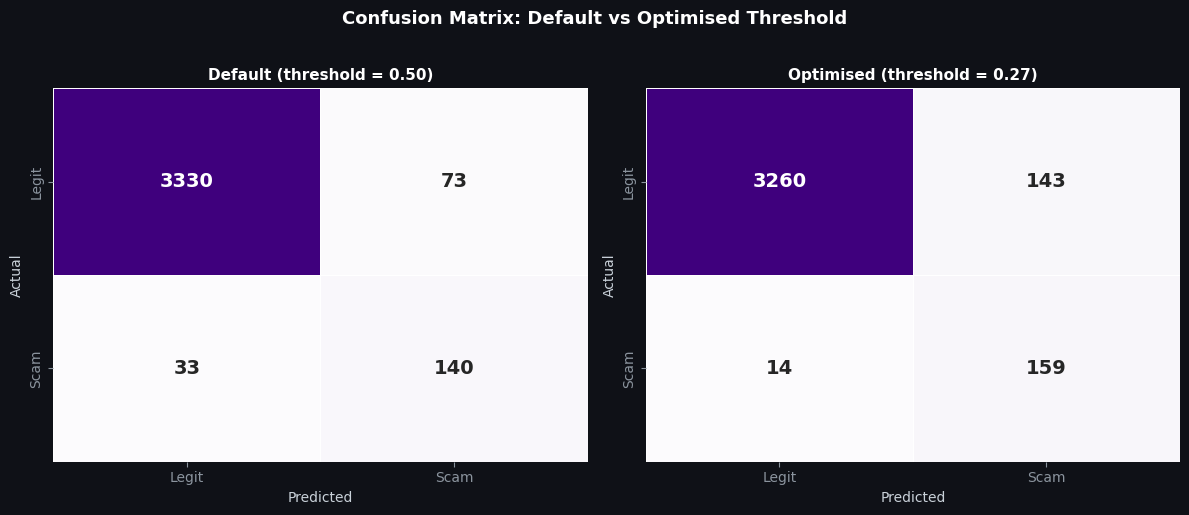

  Saved: ./outputs/confusion_matrix.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('#0f1117')

for ax, (thresh, label) in zip(axes, [
    (0.50,      'Default (threshold = 0.50)'),
    (opt_thresh, f'Optimised (threshold = {opt_thresh:.2f})')
]):
    ax.set_facecolor('#1a1d2e')
    y_pred = (y_prob >= thresh).astype(int)
    cm     = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                ax=ax, linewidths=0.5,
                xticklabels=['Legit','Scam'],
                yticklabels=['Legit','Scam'],
                cbar=False,
                annot_kws={'size': 14, 'weight': 'bold'})

    ax.set_title(label, fontsize=11, fontweight='bold', color='white')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual',    fontsize=10)

fig.suptitle('Confusion Matrix: Default vs Optimised Threshold',
             fontsize=13, fontweight='bold', color='white', y=1.02)

plt.tight_layout()
plt.savefig('./outputs/confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/confusion_matrix.png")


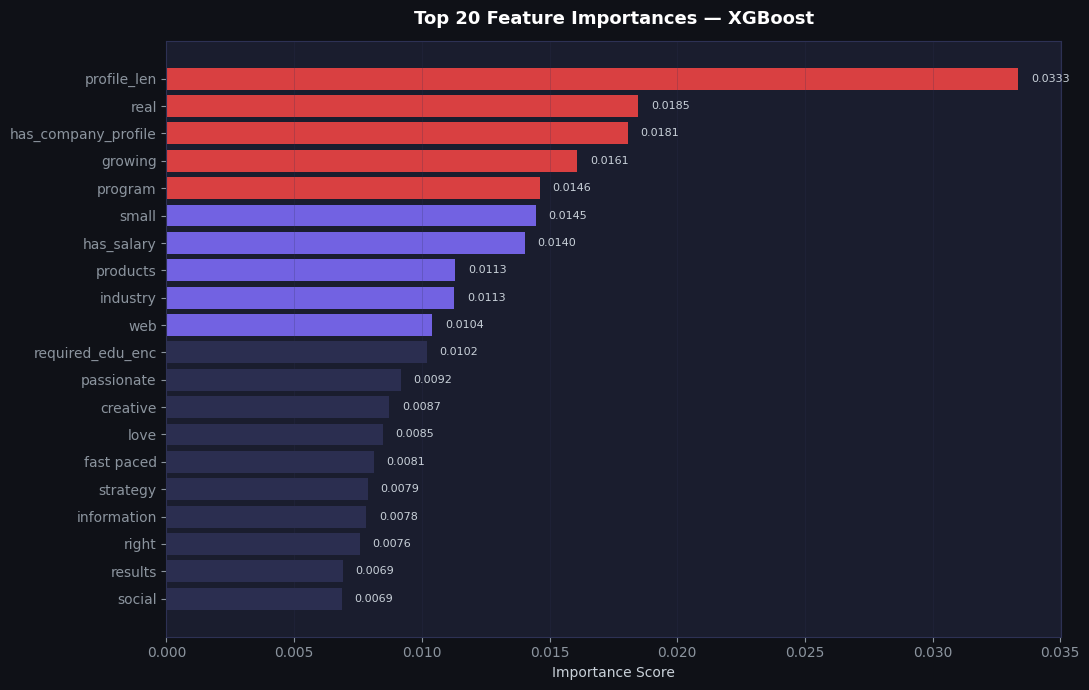

  Saved: ./outputs/feature_importance.png


In [19]:
best_model = best_res['model']

# Get importances
if best_name == 'Random Forest':
    importances = best_model.feature_importances_
else:
    importances = best_model.feature_importances_

fi = pd.Series(importances, index=feature_names).nlargest(20)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0f1117')
ax.set_facecolor('#1a1d2e')

colors = [RED if i < 5 else ACCENT if i < 10
          else '#2d3154' for i in range(len(fi))]

ax.barh(fi.index[::-1], fi.values[::-1],
        color=colors[::-1], alpha=0.9)

for i, (val, name) in enumerate(zip(fi.values[::-1], fi.index[::-1])):
    ax.text(val + 0.0005, i, f'{val:.4f}',
            va='center', fontsize=8, color='#c9d1d9')

ax.set_title(f'Top 20 Feature Importances — {best_name}',
             fontsize=13, fontweight='bold', color='white', pad=12)
ax.set_xlabel('Importance Score', fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/feature_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("  Saved: ./outputs/feature_importance.png")


In [20]:
joblib.dump(best_model, './outputs/best_model.pkl')
np.save('./outputs/optimal_threshold.npy',
        np.array([opt_thresh]))

print("  Saved:")
print(f"    ./outputs/best_model.pkl          ← {best_name}")
print(f"    ./outputs/optimal_threshold.npy   ← {opt_thresh:.4f}")
print(f"\n  Summary for your resume:")
print(f"    Model:         {best_name}")
print(f"    Test AUC:      {best_res['test_auc']:.4f}")
print(f"    CV AUC:        {best_res['cv_mean']:.4f} ± {best_res['cv_std']:.4f}")
print(f"    Opt threshold: {opt_thresh:.3f}")

  Saved:
    ./outputs/best_model.pkl          ← XGBoost
    ./outputs/optimal_threshold.npy   ← 0.2727

  Summary for your resume:
    Model:         XGBoost
    Test AUC:      0.9807
    CV AUC:        0.9778 ± 0.0076
    Opt threshold: 0.273
